# 深度学习优化方法 Tutorial
## Frontiers in Deep Learning — Optimization

本 Notebook 对应 Slides: **02_Frontiers in deep learning_2_Optimization.pdf**

---

### 目录

1. **环境准备 & 数据集**
2. **随机梯度下降 (SGD) 与 Mini-batch SGD**
   - SGD 的问题——Loss Landscape 视角
   - 改进方向：利用曲率信息
3. **加速与稳定化优化方法** (Momentum, Nesterov, LR Scheduling)
4. **高级优化器**
   - 梯度缩放方法：AdaGrad vs RMSProp
   - Adam = Momentum + RMSProp
   - Weight Decay：为什么 AdamW 比 Adam+L2 更好
   - Flat Minima 与泛化
   - Sharpness-Aware Minimization (SAM)
5. **MLP 实战：`torch.nn` 版 vs 手动参数版**
6. **分布式深度学习简介**
7. **总结 & 延伸阅读**

> 💡 所有代码均可在 **CPU** 上快速运行，无需 GPU。

---
## 1. 环境准备 & 数据集

In [1]:
import torch
import torch.nn as nn
import torch.nn.functional as F
import numpy as np
import matplotlib.pyplot as plt
from sklearn.datasets import make_moons
from sklearn.model_selection import train_test_split
from copy import deepcopy

# ---------- 全局设置 ----------
SEED = 42
torch.manual_seed(SEED)
np.random.seed(SEED)
DEVICE = torch.device("cuda" if torch.cuda.is_available() else "cpu")
print(f"Using device: {DEVICE}")

# Matplotlib 中文字体（如适用）
plt.rcParams.update({"figure.figsize": (8, 4), "axes.grid": True})

Using device: cpu


### 1.1 生成二分类数据集 (Two Moons)

我们使用 `make_moons` 生成一个简单的二分类数据集，非线性可分，非常适合展示优化器的效果。

Train: torch.Size([800, 2]), Test: torch.Size([200, 2])


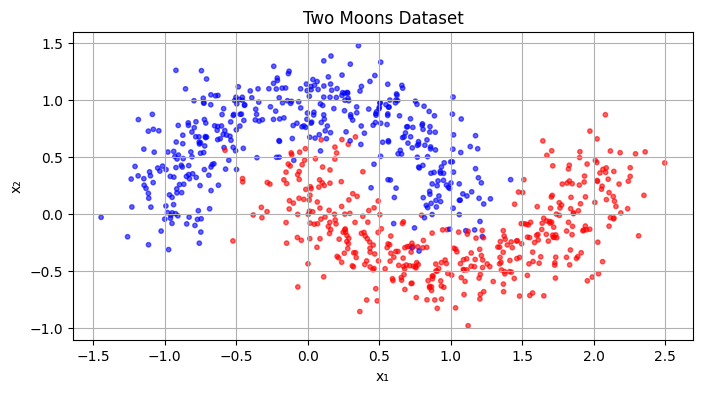

In [2]:
# 生成数据
X_np, y_np = make_moons(n_samples=1000, noise=0.2, random_state=SEED)
X_train_np, X_test_np, y_train_np, y_test_np = train_test_split(
    X_np, y_np, test_size=0.2, random_state=SEED
)

# 转为 Tensor
X_train = torch.tensor(X_train_np, dtype=torch.float32, device=DEVICE)
y_train = torch.tensor(y_train_np, dtype=torch.long, device=DEVICE)
X_test  = torch.tensor(X_test_np, dtype=torch.float32, device=DEVICE)
y_test  = torch.tensor(y_test_np, dtype=torch.long, device=DEVICE)

print(f"Train: {X_train.shape}, Test: {X_test.shape}")

# 可视化
plt.scatter(X_train_np[:, 0], X_train_np[:, 1], c=y_train_np, cmap="bwr", alpha=0.6, s=10)
plt.title("Two Moons Dataset")
plt.xlabel("x₁"); plt.ylabel("x₂")
plt.show()

### 1.2 工具函数

为方便后续实验，我们先定义一些复用的训练/评估/绘图函数。

In [3]:
def train_one_epoch(model, optimizer, X, y, batch_size=None):
    """训练一个 epoch，返回平均 loss。"""
    model.train()
    if batch_size is None or batch_size >= len(X):
        # Full-batch
        optimizer.zero_grad()
        loss = F.cross_entropy(model(X), y)
        loss.backward()
        optimizer.step()
        return loss.item()
    # Mini-batch
    indices = torch.randperm(len(X), device=X.device)
    total_loss = 0.0
    n_batches = 0
    for start in range(0, len(X), batch_size):
        idx = indices[start:start + batch_size]
        optimizer.zero_grad()
        loss = F.cross_entropy(model(X[idx]), y[idx])
        loss.backward()
        optimizer.step()
        total_loss += loss.item()
        n_batches += 1
    return total_loss / n_batches


@torch.no_grad()
def evaluate(model, X, y):
    """返回 (loss, accuracy)。"""
    model.eval()
    logits = model(X)
    loss = F.cross_entropy(logits, y).item()
    acc = (logits.argmax(dim=1) == y).float().mean().item()
    return loss, acc


def run_training(model, optimizer, n_epochs, batch_size=None,
                 X_tr=None, y_tr=None, X_te=None, y_te=None,
                 scheduler=None, clip_grad_norm=None):
    """完整训练循环，返回 history dict。"""
    if X_tr is None: X_tr, y_tr, X_te, y_te = X_train, y_train, X_test, y_test
    history = {"train_loss": [], "test_loss": [], "test_acc": []}
    for epoch in range(n_epochs):
        tr_loss = train_one_epoch(model, optimizer, X_tr, y_tr, batch_size)
        if clip_grad_norm is not None:
            nn.utils.clip_grad_norm_(model.parameters(), clip_grad_norm)
        te_loss, te_acc = evaluate(model, X_te, y_te)
        history["train_loss"].append(tr_loss)
        history["test_loss"].append(te_loss)
        history["test_acc"].append(te_acc)
        if scheduler is not None:
            scheduler.step()
    return history


def plot_histories(histories: dict, metric="train_loss", ylabel=None, title=None):
    """对比多组实验的指定 metric 曲线。"""
    plt.figure(figsize=(8, 4))
    for name, h in histories.items():
        plt.plot(h[metric], label=name)
    plt.xlabel("Epoch")
    plt.ylabel(ylabel or metric)
    plt.title(title or metric)
    plt.legend()
    plt.tight_layout()
    plt.show()

### 1.3 定义一个简单的 MLP

后续优化器对比实验全部使用 **相同的模型结构**，只换优化器。
模型：`2 → 32 → 16 → 2`（两个隐藏层，ReLU 激活）。

In [4]:
def make_mlp():
    """返回一个新的 MLP 实例（固定随机种子以保证公平对比）。"""
    torch.manual_seed(SEED)
    model = nn.Sequential(
        nn.Linear(2, 32),
        nn.ReLU(),
        nn.Linear(32, 16),
        nn.ReLU(),
        nn.Linear(16, 2),
    ).to(DEVICE)
    return model

print(make_mlp())

Sequential(
  (0): Linear(in_features=2, out_features=32, bias=True)
  (1): ReLU()
  (2): Linear(in_features=32, out_features=16, bias=True)
  (3): ReLU()
  (4): Linear(in_features=16, out_features=2, bias=True)
)


---
## 2. 随机梯度下降 (SGD) 与 Mini-batch SGD

### 2.1 梯度下降回顾

给定损失函数 $\mathcal{L}(\theta)$，参数更新规则为：

$$
\theta_{t+1} = \theta_t - \eta \nabla_{\theta} \mathcal{L}(\theta_t)
$$

其中 $\eta$ 是学习率 (learning rate)。

| 方式 | 每步使用数据量 | 特点 |
|---|---|---|
| **Full-batch GD** | 全部训练数据 $N$ | 梯度准确但计算量大，内存消耗高 |
| **SGD** | 单个样本 ($B=1$) | 梯度噪声大、更新频繁，收敛路径震荡 |
| **Mini-batch SGD** | 小批次 $B$ | 兼顾效率与稳定性，实践中最常用 |

> 📝 **直觉**：Mini-batch 越大，梯度估计越准确但每步计算越贵；越小，噪声越大但可能帮助跳出局部极小值。

### 2.2 实验：不同 batch size 对训练的影响

我们用相同的模型初始化和学习率，对比 Full-batch / batch=32 / batch=1（纯SGD）。

Full-batch GD             → Test Acc: 0.9750
Mini-batch (B=32)         → Test Acc: 0.9850
SGD (B=1)                 → Test Acc: 0.9800


/var/folders/dq/2spcfdq5241cb1mz106k99rc0000gn/T/ipykernel_98760/1809678945.py:64: UserWarning: Glyph 23545 (\N{CJK UNIFIED IDEOGRAPH-5BF9}) missing from font(s) DejaVu Sans.
  plt.tight_layout()
/var/folders/dq/2spcfdq5241cb1mz106k99rc0000gn/T/ipykernel_98760/1809678945.py:64: UserWarning: Glyph 27604 (\N{CJK UNIFIED IDEOGRAPH-6BD4}) missing from font(s) DejaVu Sans.
  plt.tight_layout()
/opt/anaconda3/envs/ml/lib/python3.9/site-packages/IPython/core/pylabtools.py:152: UserWarning: Glyph 23545 (\N{CJK UNIFIED IDEOGRAPH-5BF9}) missing from font(s) DejaVu Sans.
  fig.canvas.print_figure(bytes_io, **kw)
/opt/anaconda3/envs/ml/lib/python3.9/site-packages/IPython/core/pylabtools.py:152: UserWarning: Glyph 27604 (\N{CJK UNIFIED IDEOGRAPH-6BD4}) missing from font(s) DejaVu Sans.
  fig.canvas.print_figure(bytes_io, **kw)


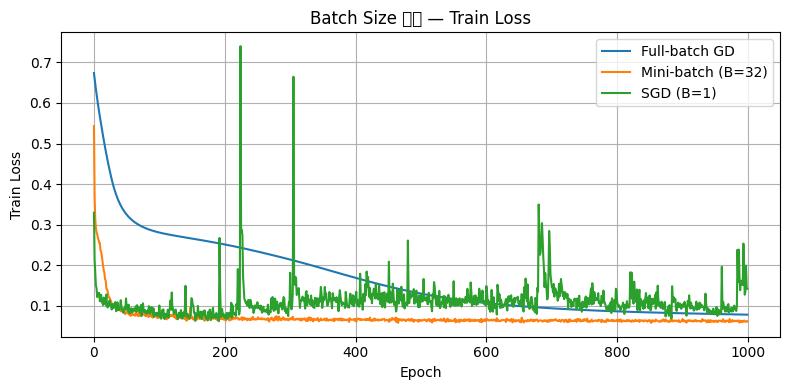

In [5]:
EPOCHS_SGD = 1000
LR = 0.1

configs = {
    "Full-batch GD": None,      # batch_size=None → 全部数据
    "Mini-batch (B=32)": 32,
    "SGD (B=1)": 1,
}

histories_bs = {}
for name, bs in configs.items():
    model = make_mlp()
    opt = torch.optim.SGD(model.parameters(), lr=LR)
    histories_bs[name] = run_training(model, opt, EPOCHS_SGD, batch_size=bs)
    _, acc = evaluate(model, X_test, y_test)
    print(f"{name:25s} → Test Acc: {acc:.4f}")

plot_histories(histories_bs, "train_loss", ylabel="Train Loss",
              title="Batch Size 对比 — Train Loss")

**观察 & 小结**：
- Full-batch GD 收敛曲线最平滑，但每个 epoch 只更新一次参数。
- SGD ($B=1$) 噪声最大，曲线抖动明显，但有时能更快找到好的 loss 区域。
- Mini-batch ($B=32$) 兼顾了计算效率与收敛稳定性——这也是实践中最常见的选择。

### 2.3 SGD 的问题——从 Loss Landscape 的角度

虽然 SGD 简单有效，但它在实际深度学习训练中面临三大挑战：

**① 各向异性梯度 (Anisotropic Gradients)**

在高维参数空间中，不同方向的曲率差异巨大。Loss landscape 可能在某些方向非常陡峭，在另一些方向非常平坦。SGD 用**同一个学习率**处理所有方向，导致：
- 在陡峭方向上步子太大 → 来回震荡
- 在平坦方向上步子太小 → 收敛缓慢

这就好比在一个又长又窄的峡谷里走，SGD 会不停地撞两边的墙。

**② 鞍点 (Saddle Points)**

在高维空间中，鞍点比局部极小值更常见。在鞍点处，某些方向梯度为零（甚至指向上方），SGD 的梯度信号极弱，导致收敛停滞。

**③ 尖锐谷 (Sharp Valleys)**

某些 loss 极小值非常"尖锐"——参数只要稍微偏移，loss 就急剧上升。这种尖锐谷的泛化能力差（参见后面的 Flat Minima 章节），而且 SGD 在小学习率下容易被困在这类区域。

> 💡 **核心启示**：这些问题都指向一个方向——我们需要更智能的更新策略，而非用固定学习率对所有参数一视同仁。

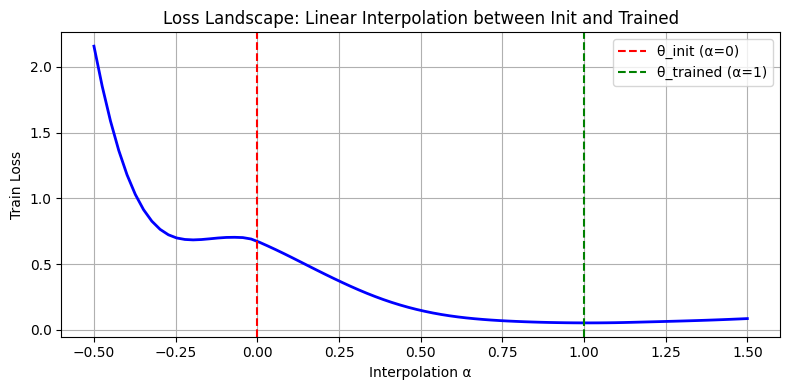

In [6]:
# 可视化 Loss Landscape：在初始化参数和训练后参数之间做线性插值
# 这个图直观展示了 loss surface 的形状

model_init = make_mlp()  # 初始化模型（checkpoint 0）
model_trained = make_mlp()  # 重新创建一份，训练后作为 checkpoint 1
opt_tmp = torch.optim.SGD(model_trained.parameters(), lr=0.1, momentum=0.9)
_ = run_training(model_trained, opt_tmp, 200, batch_size=32)

# 线性插值：θ(α) = (1 - α) * θ_init + α * θ_trained
alphas = np.linspace(-0.5, 1.5, 80)
interp_losses = []

params_init = [p.detach().clone() for p in model_init.parameters()]
params_trained = [p.detach().clone() for p in model_trained.parameters()]

for alpha in alphas:
    # 设置插值参数
    for p, p0, p1 in zip(model_init.parameters(), params_init, params_trained):
        p.data.copy_((1 - alpha) * p0 + alpha * p1)
    loss_val, _ = evaluate(model_init, X_train, y_train)
    interp_losses.append(loss_val)

# 恢复原始参数
for p, p0 in zip(model_init.parameters(), params_init):
    p.data.copy_(p0)

plt.figure(figsize=(8, 4))
plt.plot(alphas, interp_losses, "b-", linewidth=2)
plt.axvline(x=0, color="r", linestyle="--", label="θ_init (α=0)")
plt.axvline(x=1, color="g", linestyle="--", label="θ_trained (α=1)")
plt.xlabel("Interpolation α")
plt.ylabel("Train Loss")
plt.title("Loss Landscape: Linear Interpolation between Init and Trained")
plt.legend()
plt.tight_layout()
plt.show()

### 2.4 改进方向：利用曲率信息 (Curvature Information)

上面的问题本质上是 SGD **忽略了 loss surface 的曲率**——它只看一阶导数（梯度），不看二阶导数（Hessian）。

#### 牛顿法的理想与现实

理想的更新应该用 Hessian 矩阵 $H$ 来校正方向：

$$
\theta_{t+1} = \theta_t - H^{-1} \nabla_\theta \mathcal{L}(\theta_t)
$$

在陡峭方向（Hessian 特征值大）自动缩小步长，在平坦方向（特征值小）放大步长。但问题是：
- Hessian $H \in \mathbb{R}^{d \times d}$，对于百万/亿级参数模型，**存储和求逆都不可行**
- 即使用近似（L-BFGS 等），计算量仍然远超 SGD

#### 对角预条件 (Diagonal Preconditioning)

一个可行的折中：只用 Hessian 的**对角线近似**，即为每个参数独立地估计曲率：

$$
\theta_i^{(t+1)} = \theta_i^{(t)} - \frac{\eta}{h_i} g_i^{(t)}
$$

其中 $h_i$ 是第 $i$ 个参数方向的曲率估计。

> 💡 **关键洞察**：**AdaGrad、RMSProp、Adam 这些自适应方法，本质上就是在做对角预条件**——用历史梯度的平方来近似曲率，自动给每个参数分配不同的有效学习率。这就是为什么它们比 vanilla SGD 更聪明：
> - 梯度大的参数 → 曲率可能大 → 自动缩小学习率
> - 梯度小的参数 → 曲率可能小 → 自动放大学习率

---
## 3. 加速与稳定化优化方法

### 3.1 Momentum（动量）

Momentum 在梯度方向上叠加了**历史梯度的指数加权平均**，像一个
一样积累惯性：

$$
v_t = \mu \, v_{t-1} + \nabla_{\theta} \mathcal{L}(\theta_t)
$$
$$
\theta_{t+1} = \theta_t - \eta \, v_t
$$

- $\mu$ 通常取 **0.9**。
- 好处：加速收敛、减少震荡。

### 3.2 Nesterov Accelerated Gradient (NAG)

NAG 先
——在动量方向前瞻后再计算梯度：

$$
v_t = \mu \, v_{t-1} + \nabla_{\theta} \mathcal{L}(\theta_t - \eta \mu v_{t-1})
$$
$$
\theta_{t+1} = \theta_t - \eta \, v_t
$$

> 💡 **直觉**：Nesterov 提前在动量方向
，如果发现跑过头了可以提前修正，因此通常比普通 Momentum 收敛更快。

在 PyTorch 中只需一个参数就能开启：
```python
torch.optim.SGD(params, lr=0.1, momentum=0.9, nesterov=True)
```

### 3.3 实验：Vanilla SGD vs Momentum vs Nesterov

Vanilla SGD                    → Test Acc: 0.9900
SGD + Momentum (0.9)           → Test Acc: 0.9700
SGD + Nesterov                 → Test Acc: 0.9850


/var/folders/dq/2spcfdq5241cb1mz106k99rc0000gn/T/ipykernel_98760/1809678945.py:64: UserWarning: Glyph 23545 (\N{CJK UNIFIED IDEOGRAPH-5BF9}) missing from font(s) DejaVu Sans.
  plt.tight_layout()
/var/folders/dq/2spcfdq5241cb1mz106k99rc0000gn/T/ipykernel_98760/1809678945.py:64: UserWarning: Glyph 27604 (\N{CJK UNIFIED IDEOGRAPH-6BD4}) missing from font(s) DejaVu Sans.
  plt.tight_layout()


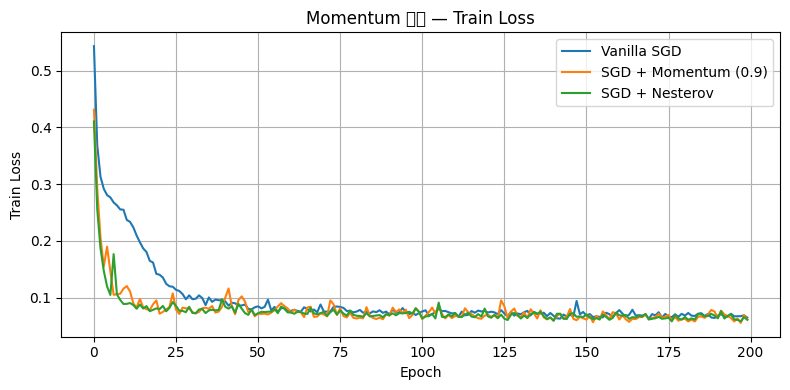

In [7]:
EPOCHS_MOM = 200

opt_configs = {
    "Vanilla SGD":            dict(lr=0.1),
    "SGD + Momentum (0.9)":   dict(lr=0.1, momentum=0.9),
    "SGD + Nesterov":         dict(lr=0.1, momentum=0.9, nesterov=True),
}

histories_mom = {}
for name, kwargs in opt_configs.items():
    model = make_mlp()
    opt = torch.optim.SGD(model.parameters(), **kwargs)
    histories_mom[name] = run_training(model, opt, EPOCHS_MOM, batch_size=32)
    _, acc = evaluate(model, X_test, y_test)
    print(f"{name:30s} → Test Acc: {acc:.4f}")

plot_histories(histories_mom, "train_loss", ylabel="Train Loss",
              title="Momentum 对比 — Train Loss")

### 3.4 学习率调度 (Learning Rate Scheduling)

固定学习率往往不够——前期需要大步快走，后期需要小步微调。常见策略：

| Scheduler | 公式/描述 |
|---|---|
| **StepLR** | 每隔 $s$ 个 epoch 乘以 $\gamma$：$\eta_t = \eta_0 \cdot \gamma^{\lfloor t/s \rfloor}$ |
| **ExponentialLR** | 每 epoch 乘 $\gamma$：$\eta_t = \eta_0 \cdot \gamma^t$ |
| **CosineAnnealingLR** | 余弦退火：$\eta_t = \eta_{\min} + \frac{1}{2}(\eta_0 - \eta_{\min})(1 + \cos(\frac{t}{T}\pi))$ |
| **ReduceLROnPlateau** | 当 loss 不再下降时自动降低 LR |

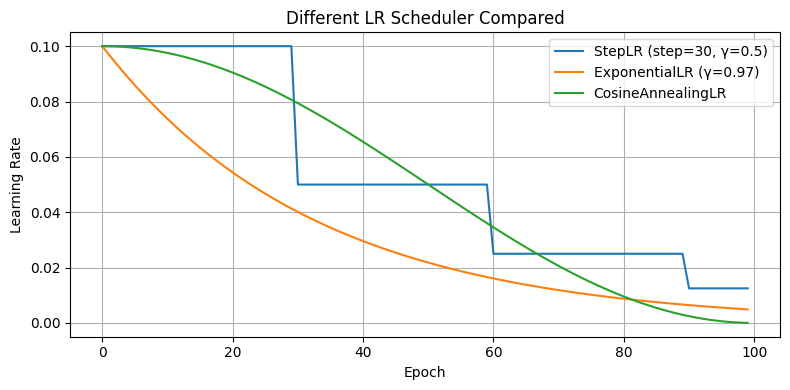

In [8]:
# 可视化不同 scheduler 的 LR 变化曲线
EPOCHS_LR = 100
init_lr = 0.1

schedulers_cfg = {
    "StepLR (step=30, γ=0.5)": lambda opt: torch.optim.lr_scheduler.StepLR(opt, step_size=30, gamma=0.5),
    "ExponentialLR (γ=0.97)": lambda opt: torch.optim.lr_scheduler.ExponentialLR(opt, gamma=0.97),
    "CosineAnnealingLR": lambda opt: torch.optim.lr_scheduler.CosineAnnealingLR(opt, T_max=EPOCHS_LR),
}

plt.figure(figsize=(8, 4))
for name, make_sched in schedulers_cfg.items():
    dummy_model = make_mlp()
    opt = torch.optim.SGD(dummy_model.parameters(), lr=init_lr)
    sched = make_sched(opt)
    lrs = []
    for _ in range(EPOCHS_LR):
        lrs.append(opt.param_groups[0]["lr"])
        opt.step()    # dummy step
        sched.step()
    plt.plot(lrs, label=name)
plt.xlabel("Epoch"); plt.ylabel("Learning Rate")
plt.title("Different LR Scheduler Compared")
plt.legend(); plt.tight_layout(); plt.show()

### 3.5 实验：带 CosineAnnealing 的训练 vs 固定 LR

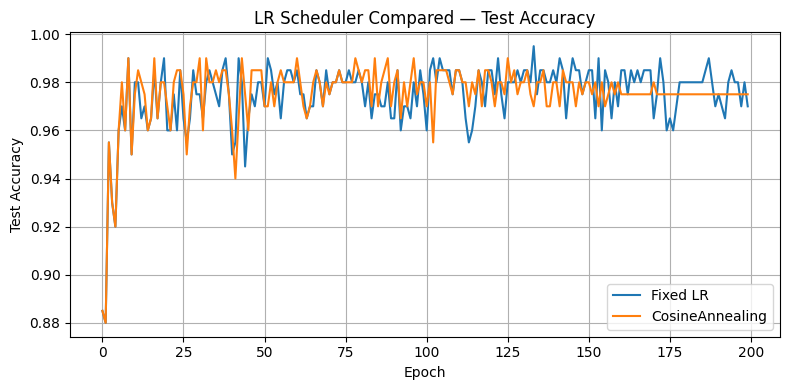

In [9]:
EPOCHS_SCHED = 200

# 固定 LR
model_fixed = make_mlp()
opt_fixed = torch.optim.SGD(model_fixed.parameters(), lr=0.1, momentum=0.9)
h_fixed = run_training(model_fixed, opt_fixed, EPOCHS_SCHED, batch_size=32)

# Cosine Annealing
model_cos = make_mlp()
opt_cos = torch.optim.SGD(model_cos.parameters(), lr=0.1, momentum=0.9)
sched_cos = torch.optim.lr_scheduler.CosineAnnealingLR(opt_cos, T_max=EPOCHS_SCHED)
h_cos = run_training(model_cos, opt_cos, EPOCHS_SCHED, batch_size=32, scheduler=sched_cos)

plot_histories({"Fixed LR": h_fixed, "CosineAnnealing": h_cos},
              metric="test_acc", ylabel="Test Accuracy",
              title="LR Scheduler Compared — Test Accuracy")

---
## 4. 高级优化器

### 4.1 梯度缩放方法：AdaGrad vs RMSProp

前面说到，自适应方法本质是用历史梯度的平方来近似曲率。这里我们对比两种经典的梯度缩放策略。

#### AdaGrad (Adaptive Gradient)

AdaGrad **累积所有历史梯度的平方和**，为每个参数自适应调整学习率：

$$
G_t = G_{t-1} + g_t^2
$$
$$
\theta_{t+1} = \theta_t - \frac{\eta}{\sqrt{G_t + \epsilon}} \, g_t
$$

- **优点**：对稀疏特征非常有效（如 NLP 中的词向量），不常出现的特征会获得更大的学习率
- **缺点**：$G_t$ 单调递增，学习率会持续衰减至接近零，训练后期基本"停滞"

#### RMSProp (Root Mean Square Propagation)

RMSProp 用**指数衰减的移动平均**替代了累积求和，解决了 AdaGrad 学习率归零的问题：

$$
s_t = \beta \, s_{t-1} + (1-\beta) \, g_t^2
$$
$$
\theta_{t+1} = \theta_t - \frac{\eta}{\sqrt{s_t + \epsilon}} \, g_t
$$

- $\beta$ 通常取 **0.9** 或 **0.99**
- "遗忘"较久以前的梯度信息，只关注**近期梯度分布**

#### 核心区别

| | AdaGrad | RMSProp |
|---|---|---|
| 梯度平方累积 | 全部历史求和（单调递增） | 指数移动平均（有衰减） |
| 学习率趋势 | 越来越小，最终趋近 0 | 保持在合理范围，能适应变化 |
| 适合场景 | 稀疏特征（NLP 等） | 非平稳目标（深度网络训练） |

> 💡 简单记：AdaGrad 对"见过多少"敏感，RMSProp 对"最近见到什么"敏感。

#### 实验：AdaGrad vs RMSProp vs SGD

SGD (lr=0.1)              → Test Acc: 0.9900
Adagrad (lr=0.1)          → Test Acc: 0.9900
RMSProp (lr=0.01)         → Test Acc: 0.9850


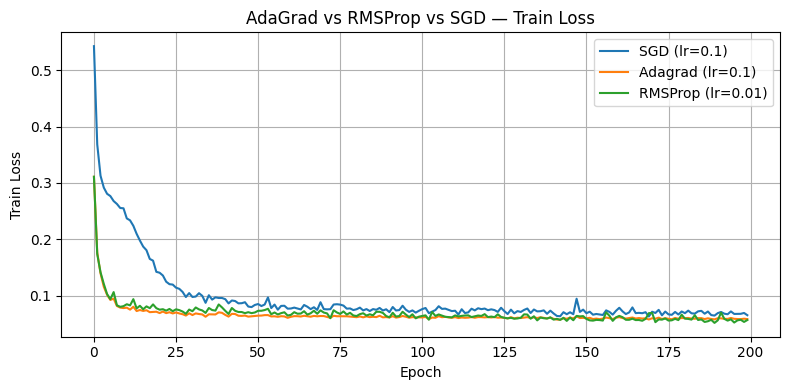

In [10]:
EPOCHS_GRAD_SCALE = 200

grad_scale_opts = {
    "SGD (lr=0.1)":      lambda p: torch.optim.SGD(p, lr=0.1),
    "Adagrad (lr=0.1)":  lambda p: torch.optim.Adagrad(p, lr=0.1),
    "RMSProp (lr=0.01)": lambda p: torch.optim.RMSprop(p, lr=0.01),
}

histories_gs = {}
for name, make_opt in grad_scale_opts.items():
    model = make_mlp()
    opt = make_opt(model.parameters())
    histories_gs[name] = run_training(model, opt, EPOCHS_GRAD_SCALE, batch_size=32)
    _, acc = evaluate(model, X_test, y_test)
    print(f"{name:25s} → Test Acc: {acc:.4f}")

plot_histories(histories_gs, "train_loss", ylabel="Train Loss",
              title="AdaGrad vs RMSProp vs SGD — Train Loss")

> 📝 **观察**：AdaGrad 前期下降很快（自适应学习率大），但后期可能停滞（累积平方和过大）。RMSProp 通过衰减历史信息避免了这个问题，后期仍能保持合理的更新幅度。

### 4.2 Adam：Momentum + RMSProp 的结合

理解了 Momentum 和 RMSProp 之后，Adam 就很自然了——它**同时维护两个统计量**：

| 组件 | 来源 | 作用 |
|---|---|---|
| $m_t$（一阶矩） | 来自 **Momentum** | 平滑梯度方向，减少噪声，加速收敛 |
| $v_t$（二阶矩） | 来自 **RMSProp** | 估计每个参数的曲率，自适应缩放学习率 |

完整更新规则：

$$
m_t = \beta_1 m_{t-1} + (1-\beta_1) g_t \quad \text{← Momentum 项}
$$
$$
v_t = \beta_2 v_{t-1} + (1-\beta_2) g_t^2 \quad \text{← RMSProp 项}
$$

**偏差修正 (Bias Correction)**：训练初期 $m_t, v_t$ 均被初始化为 0，会严重偏低。Adam 通过除以 $(1-\beta^t)$ 来修正：

$$
\hat{m}_t = \frac{m_t}{1-\beta_1^t}, \quad \hat{v}_t = \frac{v_t}{1-\beta_2^t}
$$

最终更新：

$$
\theta_{t+1} = \theta_t - \frac{\eta}{\sqrt{\hat{v}_t} + \epsilon} \hat{m}_t
$$

默认超参数：$\beta_1=0.9$, $\beta_2=0.999$, $\epsilon=10^{-8}$, $\eta=0.001$

> 💡 **为什么 Adam 这么流行？** 它几乎不需要调参就能在很多任务上表现不错——momentum 提供加速，RMSProp 提供适应性，偏差修正保证初期稳定。

### 4.3 实验：多种优化器对比

SGD+Momentum              → Test Acc: 0.9700
RMSProp                   → Test Acc: 0.9850
Adam                      → Test Acc: 0.9750
AdamW (wd=1e-2)           → Test Acc: 0.9750


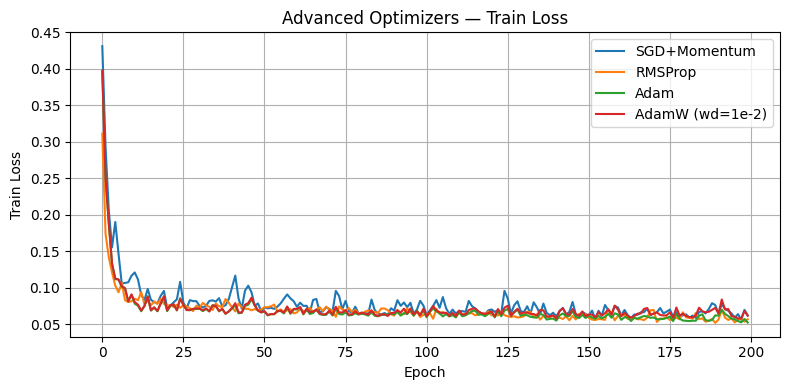

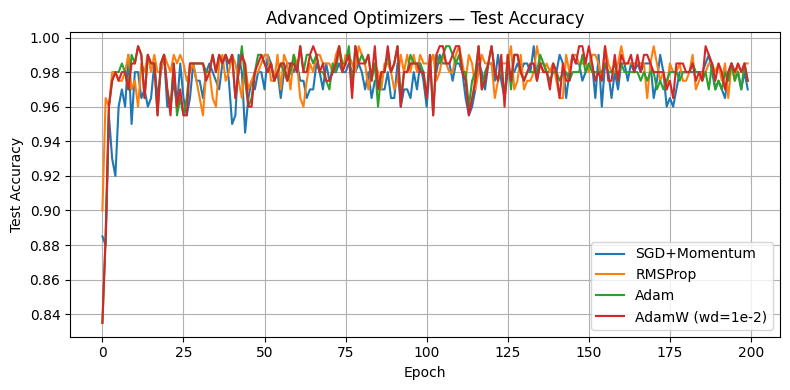

In [11]:
EPOCHS_ADV = 200

advanced_opts = {
    "SGD+Momentum":  lambda p: torch.optim.SGD(p, lr=0.1, momentum=0.9),
    "RMSProp":       lambda p: torch.optim.RMSprop(p, lr=0.01),
    "Adam":          lambda p: torch.optim.Adam(p, lr=0.01),
    "AdamW (wd=1e-2)": lambda p: torch.optim.AdamW(p, lr=0.01, weight_decay=1e-2),
}

histories_adv = {}
for name, make_opt in advanced_opts.items():
    model = make_mlp()
    opt = make_opt(model.parameters())
    histories_adv[name] = run_training(model, opt, EPOCHS_ADV, batch_size=32)
    _, acc = evaluate(model, X_test, y_test)
    print(f"{name:25s} → Test Acc: {acc:.4f}")

plot_histories(histories_adv, "train_loss", ylabel="Train Loss",
              title="Advanced Optimizers — Train Loss")
plot_histories(histories_adv, "test_acc", ylabel="Test Accuracy",
              title="Advanced Optimizers — Test Accuracy")

### 4.4 Weight Decay：为什么 AdamW 比 Adam + L2 更好？

#### L2 正则 vs 解耦 Weight Decay

在 **SGD** 中，L2 正则和 weight decay 是等价的：

$$
\text{SGD + L2}: \quad \theta_{t+1} = \theta_t - \eta \left( g_t + \lambda \theta_t \right) = (1 - \eta\lambda) \theta_t - \eta g_t
$$

但在 **Adam** 中，梯度被自适应缩放了，如果 weight decay 加在梯度上（L2 方式），正则项也会被缩放，导致正则效果**因参数而异，不可控**：

$$
\text{Adam + L2}: \quad \theta_{t+1} = \theta_t - \frac{\eta}{\sqrt{\hat{v}_t} + \epsilon} \left( \hat{m}_t + \lambda \theta_t \right) \quad \leftarrow \text{❌ λθ 也被缩放了！}
$$

**AdamW 的解法**：把 weight decay **解耦**出来，不经过自适应缩放：

$$
\text{AdamW}: \quad \theta_{t+1} = (1 - \lambda) \theta_t - \frac{\eta}{\sqrt{\hat{v}_t} + \epsilon} \hat{m}_t \quad \leftarrow \text{✅ λ 独立作用}
$$

> 💡 **结论**：用 Adam 系列时，**必须用 `AdamW`** 而不是 `Adam(weight_decay=...)`。后者实际做的是 L2 正则而非真正的 weight decay。

#### Gradient Clipping

梯度爆炸时（尤其 RNN/Transformer），可以限制梯度的范数：

$$
\text{if } \|g\| > \text{max\_norm}: \quad g \leftarrow g \cdot \frac{\text{max\_norm}}{\|g\|}
$$

```python
torch.nn.utils.clip_grad_norm_(model.parameters(), max_norm=1.0)
```

SGD + WD (λ=1e-2)              → Acc: 0.9700, ||θ||: 5.0630
Adam + L2 (λ=1e-2)             → Acc: 0.9800, ||θ||: 5.0257
AdamW (λ=1e-2)                 → Acc: 0.9750, ||θ||: 14.6290
AdamW (no WD)                  → Acc: 0.9750, ||θ||: 19.6976


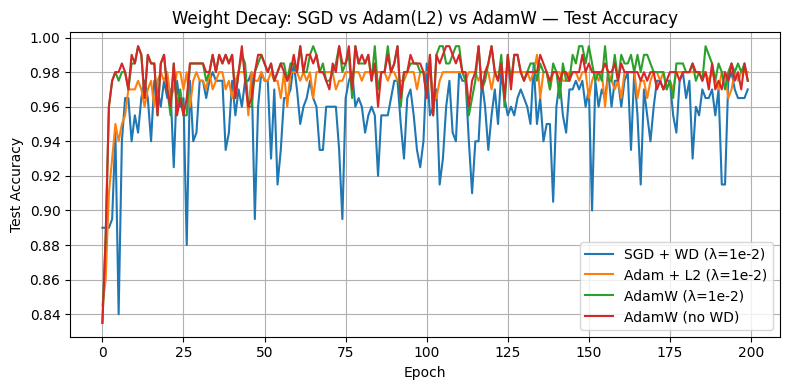

In [12]:
# Weight Decay 对比：SGD+WD vs Adam+L2 vs AdamW
wd_compare = {
    "SGD + WD (λ=1e-2)":   lambda p: torch.optim.SGD(p, lr=0.1, momentum=0.9, weight_decay=1e-2),
    "Adam + L2 (λ=1e-2)":  lambda p: torch.optim.Adam(p, lr=0.01, weight_decay=1e-2),
    "AdamW (λ=1e-2)":      lambda p: torch.optim.AdamW(p, lr=0.01, weight_decay=1e-2),
    "AdamW (no WD)":        lambda p: torch.optim.AdamW(p, lr=0.01, weight_decay=0),
}

histories_wd = {}
for name, make_opt in wd_compare.items():
    model = make_mlp()
    opt = make_opt(model.parameters())
    histories_wd[name] = run_training(model, opt, 200, batch_size=32)

    param_norm = sum(p.norm().item()**2 for p in model.parameters())**0.5
    _, acc = evaluate(model, X_test, y_test)
    print(f"{name:30s} → Acc: {acc:.4f}, ||θ||: {param_norm:.4f}")

plot_histories(histories_wd, "test_acc", ylabel="Test Accuracy",
              title="Weight Decay: SGD vs Adam(L2) vs AdamW — Test Accuracy")

> 📝 **观察**：
> - AdamW 的参数范数 $\|\theta\|$ 通常小于 Adam+L2，说明解耦 weight decay 正则效果更稳定。
> - SGD+WD 和 AdamW 都能有效控制参数大小，但 AdamW 收敛更快（受益于自适应学习率）。
> - Adam+L2 的正则效果不如 AdamW，因为 L2 项也被自适应缩放，大梯度方向正则过弱，小梯度方向正则过强。

### 4.5 Flat Minima 与泛化

#### 尖锐极小 vs 平坦极小

直觉上，loss landscape 中的极小值可以分为两类：

- **Sharp Minimum（尖锐极小）**：参数任何微小扰动都会导致 loss 急剧上升。训练集上表现好，但**泛化差**——因为测试数据引起的分布偏移就相当于参数扰动。
- **Flat Minimum（平坦极小）**：参数在一定范围内扰动，loss 变化不大。训练和测试性能更一致，**泛化好**。

数学上，可以用 **Hessian 的特征值**来衡量锐度：
- 特征值大 → 方向曲率大 → 尖锐
- 特征值小 → 方向平坦 → 平坦

#### 为什么要关心 Flat Minima？

Hochreiter & Schmidhuber (1997) 就提出了"flat minima → better generalization"的假说。近年来随着大模型训练，这个观点得到了广泛验证：
- **大 batch size** 训练往往收敛到尖锐极小，泛化差
- **小 batch size / SGD noise** 像天然的正则化，帮助逃离尖锐区域
- 专门的优化器（如 SAM）可以主动寻找平坦区域

#### 实验：探测极小值的"锐度"

我们分别用不同优化器训练模型，然后通过**随机扰动参数**来测量 loss 的变化幅度——变化越大，说明该极小值越尖锐。

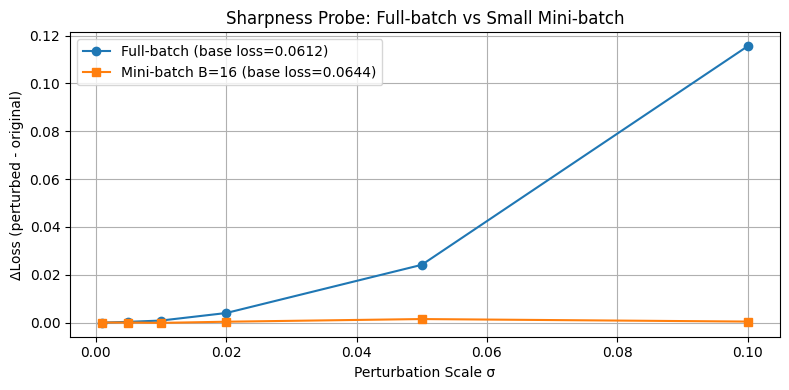

In [13]:
def measure_sharpness(model, X, y, noise_scales, n_trials=10):
    """给模型参数加高斯噪声，测量 loss 变化。"""
    base_loss, _ = evaluate(model, X, y)
    results = {}
    params_backup = [p.detach().clone() for p in model.parameters()]
    for scale in noise_scales:
        losses = []
        for _ in range(n_trials):
            # 扰动参数
            with torch.no_grad():
                for p, p0 in zip(model.parameters(), params_backup):
                    p.data.copy_(p0 + scale * torch.randn_like(p))
            loss_val, _ = evaluate(model, X, y)
            losses.append(loss_val)
            # 恢复
            with torch.no_grad():
                for p, p0 in zip(model.parameters(), params_backup):
                    p.data.copy_(p0)
        results[scale] = np.mean(losses) - base_loss
    return base_loss, results

# 用大 batch (full-batch) 和小 batch 分别训练
torch.manual_seed(SEED)
model_large_bs = make_mlp()
opt_lb = torch.optim.SGD(model_large_bs.parameters(), lr=0.1, momentum=0.9)
_ = run_training(model_large_bs, opt_lb, 300, batch_size=None)  # full-batch

torch.manual_seed(SEED)
model_small_bs = make_mlp()
opt_sb = torch.optim.SGD(model_small_bs.parameters(), lr=0.1, momentum=0.9)
_ = run_training(model_small_bs, opt_sb, 300, batch_size=16)  # small batch

noise_scales = [0.001, 0.005, 0.01, 0.02, 0.05, 0.1]

base_lb, sharp_lb = measure_sharpness(model_large_bs, X_train, y_train, noise_scales)
base_sb, sharp_sb = measure_sharpness(model_small_bs, X_train, y_train, noise_scales)

plt.figure(figsize=(8, 4))
plt.plot(noise_scales, list(sharp_lb.values()), "o-", label=f"Full-batch (base loss={base_lb:.4f})")
plt.plot(noise_scales, list(sharp_sb.values()), "s-", label=f"Mini-batch B=16 (base loss={base_sb:.4f})")
plt.xlabel("Perturbation Scale σ")
plt.ylabel("ΔLoss (perturbed - original)")
plt.title("Sharpness Probe: Full-batch vs Small Mini-batch")
plt.legend()
plt.tight_layout()
plt.show()

> 📝 **观察**：小 batch 训练的模型在参数扰动下 loss 变化更小（更平坦），而 full-batch 训练的模型更"尖锐"。这解释了为什么小 batch SGD 通常泛化更好——SGD 的梯度噪声充当了隐式正则化，帮助模型找到更平坦的极小值。

### 4.6 Sharpness-Aware Minimization (SAM)

既然平坦极小值泛化更好，能否让优化器**主动寻找平坦区域**？这就是 SAM 的核心思想。

#### SAM 的更新规则

SAM 不是直接最小化 $\mathcal{L}(\theta)$，而是最小化"最坏情况下的 loss"——即在参数邻域内找到 loss 最大的方向，然后对这个最大 loss 求梯度：

$$
\min_\theta \max_{\|\epsilon\| \leq \rho} \mathcal{L}(\theta + \epsilon)
$$

实际计算分两步：

**Step 1 — 上升步 (Ascent)**：找到使 loss 最大的扰动方向

$$
\hat{\epsilon}(\theta) = \rho \frac{\nabla_\theta \mathcal{L}(\theta)}{\|\nabla_\theta \mathcal{L}(\theta)\|}
$$

**Step 2 — 下降步 (Descent)**：在扰动后的位置计算梯度，用于实际更新

$$
\theta_{t+1} = \theta_t - \eta \nabla_\theta \mathcal{L}(\theta_t + \hat{\epsilon}(\theta_t))
$$

> 💡 **直觉**：SAM 先故意把参数推向 loss 变大的方向，然后在那个"最陡"的地方求梯度来更新。这迫使优化器远离尖锐区域，因为尖锐极小值的"最坏情况"很差，而平坦极小值的"最坏情况"还不错。

#### SAM 的 PyTorch 实现

下面是一个轻量的 SAM 实现（封装任意基础优化器）：

In [14]:
class SAM(torch.optim.Optimizer):
    """Sharpness-Aware Minimization (SAM), 包装任意基础优化器。"""
    def __init__(self, params, base_optimizer, rho=0.05, **kwargs):
        defaults = dict(rho=rho, **kwargs)
        super().__init__(params, defaults)
        self.base_optimizer = base_optimizer(self.param_groups, **kwargs)

    @torch.no_grad()
    def first_step(self):
        """Step 1: 沿梯度方向扰动参数 (ascent)。"""
        grad_norm = self._grad_norm()
        for group in self.param_groups:
            scale = group["rho"] / (grad_norm + 1e-12)
            for p in group["params"]:
                if p.grad is None:
                    continue
                # 保存当前参数
                self.state[p]["old_p"] = p.data.clone()
                # 扰动: θ + ε
                e_w = p.grad * scale
                p.add_(e_w)

    @torch.no_grad()
    def second_step(self):
        """Step 2: 恢复参数，用扰动点的梯度更新 (descent)。"""
        for group in self.param_groups:
            for p in group["params"]:
                if p.grad is None:
                    continue
                p.data = self.state[p]["old_p"]  # 恢复原始参数
        self.base_optimizer.step()

    def _grad_norm(self):
        shared_device = self.param_groups[0]["params"][0].device
        norm = torch.norm(
            torch.stack([
                p.grad.norm(p=2).to(shared_device)
                for group in self.param_groups
                for p in group["params"]
                if p.grad is not None
            ]),
            p=2,
        )
        return norm

#### 实验：SAM vs SGD vs Adam

注意 SAM 每步需要两次前向+反向传播（ascent + descent），所以计算量是普通优化器的约 2 倍。

SAM(SGD)     → Test Acc: 0.9750
SGD+Mom      → Test Acc: 0.9700
Adam         → Test Acc: 0.9750


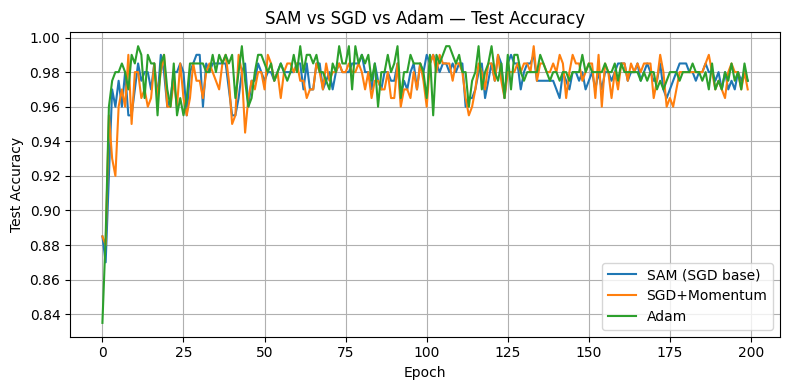

In [15]:
def train_sam_epoch(model, sam_opt, X, y, batch_size=32):
    """SAM 专用训练循环（每步两次前向反向）。"""
    model.train()
    indices = torch.randperm(len(X), device=X.device)
    total_loss = 0.0
    n_batches = 0
    for start in range(0, len(X), batch_size):
        idx = indices[start:start + batch_size]
        # Step 1: 计算梯度 → ascent
        loss = F.cross_entropy(model(X[idx]), y[idx])
        loss.backward()
        sam_opt.first_step()
        sam_opt.zero_grad()
        # Step 2: 在扰动后位置计算梯度 → descent
        F.cross_entropy(model(X[idx]), y[idx]).backward()
        sam_opt.second_step()
        sam_opt.zero_grad()
        total_loss += loss.item()
        n_batches += 1
    return total_loss / n_batches


EPOCHS_SAM = 200

# --- SAM (SGD base) ---
torch.manual_seed(SEED)
model_sam = make_mlp()
sam_opt = SAM(model_sam.parameters(), base_optimizer=torch.optim.SGD, rho=0.05, lr=0.1, momentum=0.9)
h_sam = {"train_loss": [], "test_loss": [], "test_acc": []}
for ep in range(EPOCHS_SAM):
    tr_loss = train_sam_epoch(model_sam, sam_opt, X_train, y_train, batch_size=32)
    te_loss, te_acc = evaluate(model_sam, X_test, y_test)
    h_sam["train_loss"].append(tr_loss)
    h_sam["test_loss"].append(te_loss)
    h_sam["test_acc"].append(te_acc)

# --- Vanilla SGD ---
model_sgd_cmp = make_mlp()
opt_sgd_cmp = torch.optim.SGD(model_sgd_cmp.parameters(), lr=0.1, momentum=0.9)
h_sgd_cmp = run_training(model_sgd_cmp, opt_sgd_cmp, EPOCHS_SAM, batch_size=32)

# --- Adam ---
model_adam_cmp = make_mlp()
opt_adam_cmp = torch.optim.Adam(model_adam_cmp.parameters(), lr=0.01)
h_adam_cmp = run_training(model_adam_cmp, opt_adam_cmp, EPOCHS_SAM, batch_size=32)

for name, m in [("SAM(SGD)", model_sam), ("SGD+Mom", model_sgd_cmp), ("Adam", model_adam_cmp)]:
    _, acc = evaluate(m, X_test, y_test)
    print(f"{name:12s} → Test Acc: {acc:.4f}")

plot_histories({"SAM (SGD base)": h_sam, "SGD+Momentum": h_sgd_cmp, "Adam": h_adam_cmp},
              metric="test_acc", ylabel="Test Accuracy",
              title="SAM vs SGD vs Adam — Test Accuracy")

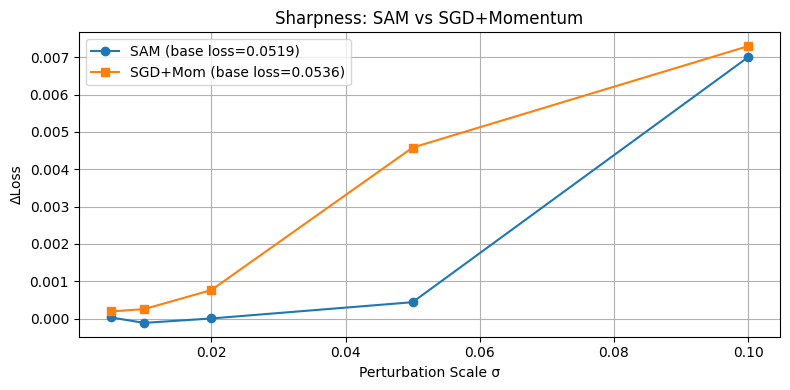

In [16]:
# 用锐度探针对比 SAM vs SGD 训练结果的平坦度
noise_scales_sam = [0.005, 0.01, 0.02, 0.05, 0.1]

base_sam, sharp_sam = measure_sharpness(model_sam, X_train, y_train, noise_scales_sam)
base_sgd_c, sharp_sgd_c = measure_sharpness(model_sgd_cmp, X_train, y_train, noise_scales_sam)

plt.figure(figsize=(8, 4))
plt.plot(noise_scales_sam, list(sharp_sam.values()), "o-", label=f"SAM (base loss={base_sam:.4f})")
plt.plot(noise_scales_sam, list(sharp_sgd_c.values()), "s-", label=f"SGD+Mom (base loss={base_sgd_c:.4f})")
plt.xlabel("Perturbation Scale σ")
plt.ylabel("ΔLoss")
plt.title("Sharpness: SAM vs SGD+Momentum")
plt.legend()
plt.tight_layout()
plt.show()

> 📝 **小结**：
> - SAM 训练的模型在参数扰动下更稳定（ΔLoss 更小），验证了它确实找到了更平坦的极小值。
> - SAM 的代价是每步需要两次梯度计算，训练时间约为普通优化器的 2 倍。
> - 在小数据/小模型上优势不一定明显，但在大规模视觉任务（如 ImageNet）上 SAM 能带来显著的泛化提升。
>
> **SAM 的扩展**：ASAM（自适应 SAM）、LookSAM（降低计算开销）、GSAM 等变体近年来不断涌现。

---
## 5. MLP 实战：`torch.nn` 版 vs 手动参数版

为了深入理解优化器到底在做什么，我们用**两种方式**实现 MLP 训练：
1. **`torch.nn` 版本**：用 `nn.Module` / `nn.Sequential` 封装，调用 `optimizer.step()` 更新。
2. **手动参数版本**：用 `torch.nn.Parameter` + `F.linear` / `F.relu` 手写前向传播，optimizer 操作参数列表。

两者在数学上**完全等价**，但手动版让你看清每一步到底发生了什么。

### 5.1 方式 A：`torch.nn` 模块版 MLP

In [17]:
class MLPModule(nn.Module):
    """使用 nn.Module 定义的 MLP。"""
    def __init__(self, in_dim=2, hidden1=32, hidden2=16, out_dim=2):
        super().__init__()
        self.net = nn.Sequential(
            nn.Linear(in_dim, hidden1),
            nn.ReLU(),
            nn.Linear(hidden1, hidden2),
            nn.ReLU(),
            nn.Linear(hidden2, out_dim),
        )

    def forward(self, x):
        return self.net(x)


# 训练
torch.manual_seed(SEED)
model_module = MLPModule().to(DEVICE)
opt_module = torch.optim.Adam(model_module.parameters(), lr=0.01)
h_module = run_training(model_module, opt_module, n_epochs=200, batch_size=32)
_, acc_module = evaluate(model_module, X_test, y_test)
print(f"nn.Module MLP → Test Acc: {acc_module:.4f}")

nn.Module MLP → Test Acc: 0.9750


### 5.2 方式 B：手动参数版 MLP

这里我们**不用 `nn.Linear`**，而是手动创建 weight 和 bias 张量，用 `F.linear()` 做矩阵乘法。
优化器直接操作这些参数列表。

In [18]:
class MLPManual(nn.Module):
    """手动管理参数的 MLP，与 MLPModule 等价。"""
    def __init__(self, in_dim=2, hidden1=32, hidden2=16, out_dim=2):
        super().__init__()
        # 手动创建参数 (使用 Kaiming 初始化)
        self.W1 = nn.Parameter(torch.empty(hidden1, in_dim))
        self.b1 = nn.Parameter(torch.zeros(hidden1))
        self.W2 = nn.Parameter(torch.empty(hidden2, hidden1))
        self.b2 = nn.Parameter(torch.zeros(hidden2))
        self.W3 = nn.Parameter(torch.empty(out_dim, hidden2))
        self.b3 = nn.Parameter(torch.zeros(out_dim))

        # 初始化（与 nn.Linear 默认初始化一致）
        for W in [self.W1, self.W2, self.W3]:
            nn.init.kaiming_uniform_(W, a=np.sqrt(5))
        for b, W in [(self.b1, self.W1), (self.b2, self.W2), (self.b3, self.W3)]:
            fan_in = W.size(1)
            bound = 1 / np.sqrt(fan_in)
            nn.init.uniform_(b, -bound, bound)

    def forward(self, x):
        # 手动计算每一层：y = xW^T + b
        x = F.relu(F.linear(x, self.W1, self.b1))   # 第一隐藏层
        x = F.relu(F.linear(x, self.W2, self.b2))   # 第二隐藏层
        x = F.linear(x, self.W3, self.b3)            # 输出层（无激活）
        return x


# 训练
torch.manual_seed(SEED)
model_manual = MLPManual().to(DEVICE)
opt_manual = torch.optim.Adam(model_manual.parameters(), lr=0.01)
h_manual = run_training(model_manual, opt_manual, n_epochs=200, batch_size=32)
_, acc_manual = evaluate(model_manual, X_test, y_test)
print(f"Manual-param MLP → Test Acc: {acc_manual:.4f}")

Manual-param MLP → Test Acc: 0.9850


### 5.3 对比两种实现

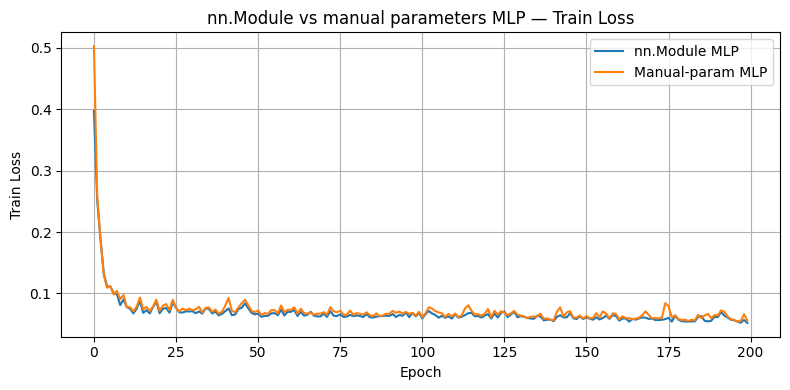

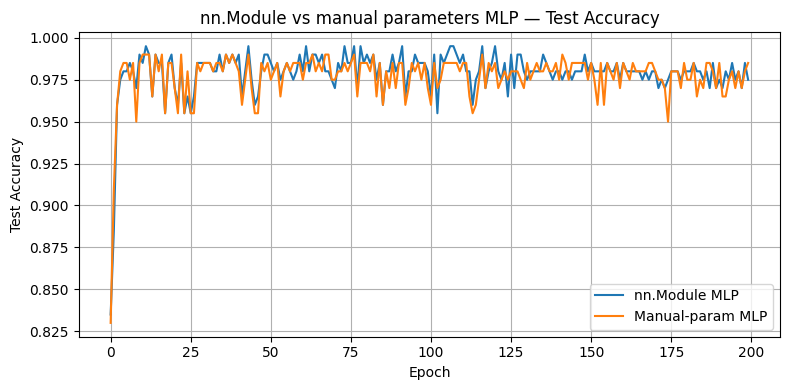


Test Accuracy Comparison:
  nn.Module: 0.9750
  manual params:   0.9850


In [19]:
plot_histories(
    {"nn.Module MLP": h_module, "Manual-param MLP": h_manual},
    metric="train_loss", ylabel="Train Loss",
    title="nn.Module vs manual parameters MLP — Train Loss"
)
plot_histories(
    {"nn.Module MLP": h_module, "Manual-param MLP": h_manual},
    metric="test_acc", ylabel="Test Accuracy",
    title="nn.Module vs manual parameters MLP — Test Accuracy"
)
print(f"\nTest Accuracy Comparison:")
print(f"  nn.Module: {acc_module:.4f}")
print(f"  manual params:   {acc_manual:.4f}")

> 📝 **结论**：两种方式在相同初始化和超参下应得到**非常相似**的结果。`nn.Module` 更简洁、工程友好；手动版帮助你理解底层原理。在实际项目中推荐使用 `nn.Module`，但理解手动版有助于调试和自定义优化策略。

### 5.4 完全手动的训练循环（不用 `optimizer.step()`）

为了更进一步理解优化器内部做了什么，我们手动实现一个 SGD 更新：

manual SGD (without optimizer) → Test Acc: 0.8900


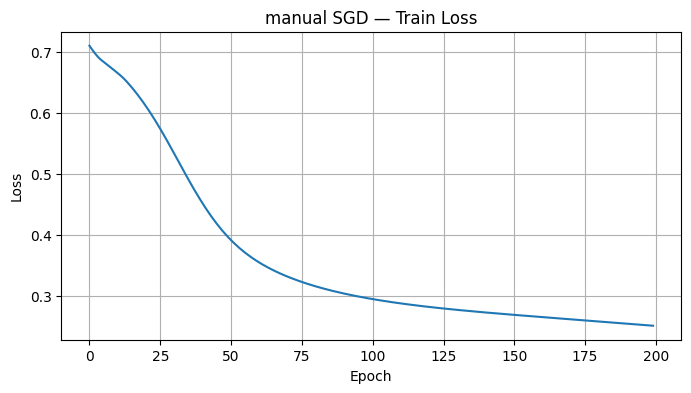

In [20]:
# 完全手动 SGD（不调用 optimizer）
torch.manual_seed(SEED)
model_raw = MLPManual().to(DEVICE)
lr_raw = 0.1
raw_losses = []

for epoch in range(200):
    # 前向传播
    logits = model_raw(X_train)
    loss = F.cross_entropy(logits, y_train)

    # 反向传播——计算梯度
    loss.backward()

    # 手动更新每个参数 (等价于 SGD)
    with torch.no_grad():
        for param in model_raw.parameters():
            param -= lr_raw * param.grad   # θ = θ - η * ∇L
            param.grad.zero_()              # 清零梯度

    raw_losses.append(loss.item())

_, acc_raw = evaluate(model_raw, X_test, y_test)
print(f"manual SGD (without optimizer) → Test Acc: {acc_raw:.4f}")

plt.plot(raw_losses)
plt.xlabel("Epoch"); plt.ylabel("Loss")
plt.title("manual SGD — Train Loss")
plt.show()

> 💡 **要点**：上面这段代码展示了优化的最底层逻辑——计算梯度、按学习率更新参数、清零梯度。`torch.optim.SGD` 做的就是这件事，只不过额外支持了 momentum、weight decay 等功能。

---
## 6. 分布式深度学习简介

当数据量或模型规模增长到单卡放不下时，需要分布式训练。

### 6.1 两种基本范式

| 范式 | 做法 | 典型场景 |
|---|---|---|
| **数据并行 (Data Parallel)** | 每张卡持有完整模型副本，数据按卡切分，梯度聚合后统一更新 | 大多数训练场景 |
| **模型并行 (Model Parallel)** | 模型按层（或按张量）切分到不同卡上，数据流经各卡 | 超大模型（GPT / LLM） |

### 6.2 Data Parallel 示意

```
数据 → [batch_0 → GPU0]  ─┐
       [batch_1 → GPU1]  ─┤  AllReduce(梯度)
       [batch_2 → GPU2]  ─┤       ↓
       [batch_3 → GPU3]  ─┘  统一更新参数
```

### 6.3 PyTorch 中的分布式 API

| API | 说明 |
|---|---|
| `nn.DataParallel` | 最简单，单进程多线程，受 GIL 限制 |
| `nn.parallel.DistributedDataParallel` (DDP) | **推荐**，多进程，通信高效 |
| `torchrun` / `torch.distributed.launch` | 启动多进程的命令行工具 |

In [21]:
# ============================================================
# DataParallel 示例代码（仅展示 API 用法，需多卡环境才真正并行）
# ============================================================

model_dp = MLPModule().to(DEVICE)

if torch.cuda.device_count() > 1:
    print(f"检测到 {torch.cuda.device_count()} 块 GPU，使用 DataParallel")
    model_dp = nn.DataParallel(model_dp)
else:
    print("仅单卡/CPU，DataParallel 不会真正并行，此处仅展示 API 用法")

# 训练方式与单卡完全一致
opt_dp = torch.optim.Adam(model_dp.parameters(), lr=0.01)
h_dp = run_training(model_dp, opt_dp, n_epochs=50, batch_size=32)
print(f"DataParallel demo done. Final test acc: {evaluate(model_dp, X_test, y_test)[1]:.4f}")

仅单卡/CPU，DataParallel 不会真正并行，此处仅展示 API 用法
DataParallel demo done. Final test acc: 0.9850


#### DDP 启动命令示例（多机多卡）

```bash
# 单机 4 卡
torchrun --nproc_per_node=4 train.py

# 多机（2 节点，每节点 4 卡）
torchrun --nnodes=2 --nproc_per_node=4 \
         --rdzv_backend=c10d --rdzv_endpoint=MASTER_IP:29500 \
         train.py
```

> 📝  DDP 中最关键的一步是 **AllReduce** 操作——所有卡同步梯度，然后各自用汇总梯度更新本地模型副本，保证一致性。

---
## 7. 总结 & 延伸阅读

### 本节核心要点

| 主题 | 关键信息 |
|---|---|
| SGD / Mini-batch | Batch size 影响梯度噪声和收敛速度；实践中 32–256 最常用 |
| Loss Landscape | SGD 面临各向异性梯度、鞍点、尖锐谷等挑战 |
| 曲率信息 | 二阶方法（Hessian）太贵；自适应方法用对角预条件近似曲率 |
| Momentum / Nesterov | 积累历史梯度加速收敛、减少震荡；NAG 提前修正方向 |
| AdaGrad vs RMSProp | AdaGrad 累积全部历史（后期衰减）；RMSProp 用衰减平均（持续适应） |
| Adam / AdamW | Adam = Momentum + RMSProp；AdamW 解耦 weight decay，大模型首选 |
| Weight Decay | Adam+L2 ≠ AdamW；解耦 weight decay 正则更稳定可控 |
| LR Scheduler | Cosine Annealing 等策略使后期微调更稳定 |
| Flat Minima | 平坦极小值泛化好；小 batch SGD 噪声是隐式正则化 |
| SAM | 主动寻找平坦极小值；两步 ascent-descent，代价 2x 但泛化更好 |
| Gradient Clipping | 防止梯度爆炸，RNN/Transformer 训练必备 |
| 分布式训练 | DDP（数据并行）是主流；超大模型需要模型并行或混合并行 |

### 延伸阅读

- Ruder, S. (2016). *An overview of gradient descent optimization algorithms.* [arXiv:1609.04747](https://arxiv.org/abs/1609.04747)
- Loshchilov & Hutter (2019). *Decoupled Weight Decay Regularization (AdamW).* [arXiv:1711.05101](https://arxiv.org/abs/1711.05101)
- Foret et al. (2021). *Sharpness-Aware Minimization for Efficiently Improving Generalization.* [arXiv:2010.01412](https://arxiv.org/abs/2010.01412)
- Hochreiter & Schmidhuber (1997). *Flat Minima.* Neural Computation.
- Li et al. (2018). *Visualizing the Loss Landscape of Neural Nets.* [arXiv:1712.09913](https://arxiv.org/abs/1712.09913)
- PyTorch 官方文档 — [Optimizers](https://pytorch.org/docs/stable/optim.html)
- PyTorch 官方文档 — [Distributed Training](https://pytorch.org/tutorials/intermediate/ddp_tutorial.html)